# Single word comparison of ENTK and Pretrained SAE similarity on Layer 6 of GPT-2

## March 27th 2025

# Introduction

In an effort to understand ENTK and SAE similarity while isolating any effects from token aggregation methods for SAEs, I examined how similarly structured phrases were to each other when changing descriptor words.

If the ENTK and SAE are similar at the word level then there is a basis for each being similar after some token aggregation method.

other idea examined include how does teh similiarity change with ... 
1) Different normalization methods (all norming methods are used in all plots) 
2) Prepending the uniform strings with eariler context tokens (see section, plot "ball" long sentence)
3) Modifier words (red, big, tiny) versus the modified noun (ball) (see section, plot describtors and plot "ball")
4) The final word (street) whcih is not directly modified by the modifier word (red, big, tiny -- ie these describe ball, not street) (see section plot "street")
5) control where the target 'word' is the entire sentence, this collapses both ENTK and SAE due to how we are averaging. (see section, plot all)



# define ML functions 

In [70]:
import re
import os
import platform
import torch
import blobfile as bf
import transformer_lens
import sparse_autoencoder
import torch.nn as nn
from tqdm.auto import trange
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

# === Group 1: Device & Model Loading Utilities ===
def get_device(skip_apple_silicon=False):
    if torch.cuda.is_available():
        device = "cuda"
        device_name = f"CUDA GPU ({torch.cuda.get_device_name(0)})"
    elif platform.processor() == 'arm' and platform.system() == 'Darwin' and not skip_apple_silicon:
        device = "mps"
        device_name = "Apple Silicon (MPS)"
    else:
        device = "cpu"
        device_name = "CPU"
    return device, device_name

def load_or_download_model(config, device):
    model_cache_dir = config.get("model_cache_dir", "./models")
    os.makedirs(model_cache_dir, exist_ok=True)
    model_path = os.path.join(model_cache_dir, "gpt2_transformer.pt")
    
    if os.path.exists(model_path):
        print("Loading model from local cache...")
        model = transformer_lens.HookedTransformer.from_pretrained("gpt2", center_writing_weights=False)
        state_dict = torch.load(model_path)
        model.load_state_dict(state_dict)
    else:
        print("Downloading model...")
        model = transformer_lens.HookedTransformer.from_pretrained("gpt2", center_writing_weights=False)
        torch.save(model.state_dict(), model_path)
        print(f"Model saved to {model_path}")
    model.to(device)
    return model

# === Group 2: NTK Utilities (focused on the target token) ===
def get_transformer_lens_hook_name(layer_index: int, location: str) -> str:
    mapping = {
        "mlp_post_act": f"blocks.{layer_index}.mlp.hook_post",
        "resid_delta_attn": f"blocks.{layer_index}.hook_attn_out",
        "resid_post_attn": f"blocks.{layer_index}.hook_resid_mid",
        "resid_delta_mlp": f"blocks.{layer_index}.hook_mlp_out",
        "resid_post_mlp": f"blocks.{layer_index}.hook_resid_post",
    }
    if location not in mapping:
        raise ValueError(f"Unknown location: {location}")
    return mapping[location]

def get_ntk_module_name(layer_index: int, location: str) -> str:
    if location in ["mlp_post_act", "resid_delta_mlp", "resid_post_mlp"]:
        return f"blocks.{layer_index}.mlp"
    elif location in ["resid_delta_attn", "resid_post_attn"]:
        return f"blocks.{layer_index}.attn"
    else:
        raise ValueError(f"Unknown location for NTK mapping: {location}")

def compute_empirical_ntk_target(model: torch.nn.Module,
                                 target_layer: str,
                                 tokens: torch.Tensor,
                                 target_first_indices: list,
                                 ntk_aggregation="N/A") -> torch.Tensor:
    """
    Computes NTK gradients only for the target token (the first token of the target span)
    in each prompt.
    """
    model.train()
    batch_size = tokens.size(0)
    modules = dict(model.named_modules())
    if target_layer not in modules:
        raise ValueError(f"Layer {target_layer} not found in the model.")
    layer_module = modules[target_layer]
    
    parameters = [p for p in layer_module.parameters() if p.requires_grad]
    n_params = sum(p.numel() for p in parameters)
    jacobian = torch.zeros(batch_size, n_params, device=tokens.device)
    
    for i in range(batch_size):
        model.zero_grad()
        sample = tokens[i:i+1]  # shape: [1, seq_len]
        logits = model(sample)  # [1, seq_len, vocab_size]
        t = target_first_indices[i]
        loss = logits[0, t, :].sum()  # dummy loss on the first token of target span
        # if ntk_aggregation == "mean":
        #     loss = loss
        loss.backward(retain_graph=True)
        
        idx = 0
        for param in parameters:
            if param.grad is None:
                raise RuntimeError("Gradient for a parameter is None.")
            grad_flat = param.grad.flatten()
            jacobian[i, idx:idx+grad_flat.numel()] = grad_flat
            idx += grad_flat.numel()
    ntk_matrix = jacobian @ jacobian.t()
    return ntk_matrix.detach()

# === Group 3: Sparse Autoencoder (SAE) Utilities (for target token) ===
def compute_sae_correlation_target(autoencoder, target_activations, sae_similarity="raw", latent_normalization=False):
    """
    Computes the SAE similarity for the target activations.
    """
    autoencoder.eval()
    with torch.no_grad():
        latent, info = autoencoder.encode(target_activations)
        if latent_normalization:
            latent = latent / (latent.norm(dim=1, keepdim=True) + 1e-8)
        if sae_similarity == "raw":
            correlation_matrix = torch.matmul(latent, latent.t())
        elif sae_similarity == "cosine":
            norm_latent = latent / (latent.norm(dim=1, keepdim=True) + 1e-8)
            correlation_matrix = torch.matmul(norm_latent, norm_latent.t())
        elif sae_similarity == "correlation":
            mean = latent.mean(dim=1, keepdim=True)
            centered = latent - mean
            std = centered.std(dim=1, keepdim=True) + 1e-8
            norm_latent = centered / std
            correlation_matrix = torch.matmul(norm_latent, norm_latent.t())
        else:
            raise ValueError(f"Unknown sae_similarity: {sae_similarity}")
    return correlation_matrix

def load_autoencoder(config, location, layer_index, device):
    autoencoder_cache_dir = config.get("autoencoder_cache_dir", "./models")
    os.makedirs(autoencoder_cache_dir, exist_ok=True)
    autoencoder_path = sparse_autoencoder.paths.v5_32k(location, layer_index)
    with bf.BlobFile(autoencoder_path, mode="rb") as f:
        state_dict = torch.load(f, weights_only=True)
        autoencoder = sparse_autoencoder.Autoencoder.from_state_dict(state_dict)
        autoencoder.to(device)
    return autoencoder

# === Group 4: Prompt Processing & Target Span Extraction ===
def get_full_prompts_and_target_spans(model, prompt_parts_list):
    """
    Given a list of prompt parts (each a list: [prefix, target, suffix]),
    construct the full prompt string and compute the token span for the target (middle string).
    Returns:
       full_prompts: list of full prompt strings.
       target_spans: list of (start, end) tuples for each prompt's target.
    """
    full_prompts = []
    target_spans = []
    for parts in prompt_parts_list:
        # Each parts: [prefix, target, suffix]
        full_prompt = "".join(parts)
        full_prompts.append(full_prompt)
        # Tokenize the prefix and target (without special tokens).
        prefix_ids = model.tokenizer.encode(parts[0], add_special_tokens=False)
        target_ids = model.tokenizer.encode(parts[1], add_special_tokens=False)
        start = len(prefix_ids)
        end = start + len(target_ids)
        target_spans.append((start, end))
    return full_prompts, target_spans

# === Group 5: Main Experiment Wrapper (using prompt parts) ===
def run_experiment_target(config, external_model=None):
    # Device setup.
    device, device_name = get_device(skip_apple_silicon=config.get("skip_apple_silicon", False))
    print(f"Using device: {device_name}")
    
    # Load model.
    model = external_model if external_model is not None else load_or_download_model(config, device)
    
    # Retrieve prompt parts list from config.
    prompt_parts_list = config.get("prompt_parts_list", [])
    # Generate full prompt strings and compute target spans.
    full_prompts, target_spans = get_full_prompts_and_target_spans(model, prompt_parts_list)
    
    # For metadata, store the target strings (middle part of each prompt).
    target_word = [parts[1] for parts in prompt_parts_list]
    
    # Run model to get activations.
    with torch.no_grad():
        logits, activation_cache = model.run_with_cache(full_prompts, remove_batch_dim=False)
    
    layer_index = config.get("layer_index", 6)
    location = config.get("location", "resid_post_mlp")
    hook_name = get_transformer_lens_hook_name(layer_index, location)
    
    # Load SAE autoencoder.
    autoencoder = load_autoencoder(config, location, layer_index, device)
    
    # Extract activations from the hook.
    activations = activation_cache[hook_name]  # shape: [batch_size, seq_len, hidden_size]
    print(f"Activations shape from hook {hook_name}: {activations.shape}")
    batch_size, seq_len, hidden_size = activations.shape
    
    # For NTK, use the first token index of each target span.
    ntk_first_indices = [span[0] for span in target_spans]
    # For SAE, average activations over the entire target span.
    sae_target_activations = []
    for i, (start, end) in enumerate(target_spans):
        token_acts = activations[i, start:end, :]
        sae_target_activations.append(token_acts.mean(dim=0))
    sae_target_activations = torch.stack(sae_target_activations, dim=0)  # [batch_size, hidden_size]
    
    # SAE Reconstruction & Correlation.
    with torch.no_grad():
        latent, info = autoencoder.encode(sae_target_activations)
        reconstructed = autoencoder.decode(latent, info)
    mse_per_sample = (reconstructed - sae_target_activations).pow(2).sum(dim=1) / sae_target_activations.pow(2).sum(dim=1)
    normalized_mse = mse_per_sample.mean().item()
    print(f"Autoencoder normalized MSE for target (middle string): {normalized_mse:.6f}")
    
    # NTK computation for target tokens (first token in each target span).
    ntk_module_name = get_ntk_module_name(layer_index, location)
    ntk_aggregation = config.get("ntk_aggregation", "N/A")
    ntk_matrix = compute_empirical_ntk_target(model, ntk_module_name, 
                                              model.to_tokens(full_prompts), 
                                              ntk_first_indices,
                                              ntk_aggregation=ntk_aggregation)
    print(f"NTK Matrix for {ntk_module_name} on target (middle) shape:", ntk_matrix.shape)
    
    # SAE Correlation computation.
    sae_similarity = config.get("sae_similarity", "raw")
    latent_normalization = config.get("latent_normalization", False)
    sae_corr_matrix = compute_sae_correlation_target(autoencoder, sae_target_activations,
                                                     sae_similarity=sae_similarity,
                                                     latent_normalization=latent_normalization)
    print("SAE Correlation Matrix for target (middle) shape:", sae_corr_matrix.shape)
    
    results = {
        "ntk_matrix": ntk_matrix,
        "sae_corr_matrix": sae_corr_matrix,
        "normalized_mse": normalized_mse,
        "metadata": {
            "ntk_aggregation": ntk_aggregation,
            "sae_similarity": sae_similarity,
            "latent_normalization": latent_normalization,
            "layer_index": layer_index,
            "location": location,
            "target_focus": "middle string",  # Indicates focus is on the middle string of the prompt parts.
            "target_word": target_word,
            # "modifier_categories": config.get("modifier_categories", {}),
            "prompt_parts_list":prompt_parts_list,
            "modifiers": config.get("modifiers", []),
            
        }
    }
    return results
    


# def generate_prompt(template: str, descriptor: str):
#     """
#     Replace the placeholder '!!!!' in the template with the given descriptor.
#     The template should have a focus marker: text enclosed in **.
#     The focus marker indicates the target part.
#     Returns:
#       - the full prompt (with the asterisks removed)
#       - a list of three strings: [prefix, target, suffix]
#     """
#     # Replace the placeholder with the descriptor.
#     prompt = template.replace("!!!!", descriptor)
    
#     # Find the focus marker (text enclosed in **)
#     match = re.search(r"\*\*(.*?)\*\*", prompt)
#     if not match:
#         raise ValueError("No focus marker (text enclosed in ** ) found in prompt.")
    
#     focus_text = match.group(1)
    
#     # Remove the asterisks from the prompt.
#     prompt_clean = prompt.replace(f"**{focus_text}**", focus_text)
    
#     # Split the clean prompt into three parts: before, target, after.
#     split_index = prompt_clean.find(focus_text)
#     prefix = prompt_clean[:split_index]
#     target = focus_text
#     suffix = prompt_clean[split_index + len(focus_text):]
    
#     # Ensure there is always a prefix and suffix (even if empty).
#     if prefix is None:
#         prefix = ""
#     if suffix is None:
#         suffix = ""
    
#     return prompt_clean, [prefix, target, suffix]


def generate_prompt(template: str, descriptor: str):
    """
    Replace '!!!!' in template with descriptor.
    Focus marker is **target**, used to extract [prefix, target, suffix].
    Returns:
        - full prompt with asterisks removed
        - [prefix, target, suffix] split from the cleaned prompt
    """
    # Insert descriptor
    prompt = template.replace("!!!!", descriptor)
    
    # Find the exact span of the focus marker **...**
    match = re.search(r"\*\*(.*?)\*\*", prompt)
    if not match:
        raise ValueError("No focus marker (text enclosed in **) found in prompt.")
    
    start, end = match.span()
    target = match.group(1)
    
    # Remove ** from prompt
    prompt_clean = prompt[:start] + target + prompt[end:]
    
    # Split into prefix, target, suffix
    prefix = prompt_clean[:start]
    suffix = prompt_clean[start + len(target):]
    
    return prompt_clean, [prefix, target, suffix]




## results_list_describer


In [71]:


# === Example Usage in Main Function ===
if __name__ == "__main__":
    # Define a list of descriptors (colors, adjectives, etc.)
    descriptors = [
                   "red", "blue", "green", "yellow", "purple",
                   "tiny", "small", "petite", 
                   "huge", "massive", "immense"
                  ]
    
    # Define your template.
    # In this example, the template has:
    # - "!!!!" as the placeholder to be replaced by each descriptor.
    # - "**ball**" as the focus word. (You can change the placement of asterisks to switch the target.)
    template = "The **!!!!** ball bounces down the street"
    
    prompt_parts_list = []  # Each element will be [prefix, target, suffix]
    modifiers = []          # To store the descriptor used for each prompt.
    
    # Generate prompts using each descriptor.
    for descriptor in descriptors:
        prompt_str, parts = generate_prompt(template, descriptor)
        prompt_parts_list.append(parts)
        modifiers.append(descriptor)
    
    display(prompt_parts_list)

        
    # Base configuration.
    base_config = {
        "skip_apple_silicon": False,
        "model_cache_dir": "./models",
        "autoencoder_cache_dir": "./models",
        "layer_index": 6,
        "location": "resid_post_mlp",
        "prompt_parts_list": prompt_parts_list,
        #"ntk_aggregation": "N/A",
        "latent_normalization": False,  # will be looped over
        "modifiers": descriptors,
    }
    
    # List of SAE similarity options to test.
    sae_similarities = ["raw", "cosine", "correlation"]
    
    results_list_describer = []
    for latent_norm in [False, True]:
        for sae_sim in sae_similarities:
            config = base_config.copy()
            config["latent_normalization"] = latent_norm
            config["sae_similarity"] = sae_sim
            print(f"\nRunning experiment with SAE similarity: {sae_sim} and latent_normalization: {latent_norm}")
            results = run_experiment_target(config)
            results_list_describer.append(results)
    
    # (Results now contain NTK and SAE matrices computed solely on the middle string of each prompt.)
    # You can then pass results_list_describer to your plotting functions.
    for i, res in enumerate(results_list_describer):
        print(f"\n--- Experiment {i+1} ---")
        for key, value in res["metadata"].items():
            print(f"{key}: {value}")




[['The ', 'red', ' ball bounces down the street'],
 ['The ', 'blue', ' ball bounces down the street'],
 ['The ', 'green', ' ball bounces down the street'],
 ['The ', 'yellow', ' ball bounces down the street'],
 ['The ', 'purple', ' ball bounces down the street'],
 ['The ', 'tiny', ' ball bounces down the street'],
 ['The ', 'small', ' ball bounces down the street'],
 ['The ', 'petite', ' ball bounces down the street'],
 ['The ', 'huge', ' ball bounces down the street'],
 ['The ', 'massive', ' ball bounces down the street'],
 ['The ', 'immense', ' ball bounces down the street']]


Running experiment with SAE similarity: raw and latent_normalization: False
Using device: Apple Silicon (MPS)
Loading model from local cache...
Loaded pretrained model gpt2 into HookedTransformer


/var/folders/tt/09f88c3d02g3m67kkqd3fd700000gn/T/ipykernel_30546/880812735.py:35: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path)


Moving model to device:  mps
Activations shape from hook blocks.6.hook_resid_post: torch.Size([11, 9, 768])
Autoencoder normalized MSE for target (middle string): 0.045022
NTK Matrix for blocks.6.mlp on target (middle) shape: torch.Size([11, 11])
SAE Correlation Matrix for target (middle) shape: torch.Size([11, 11])

Running experiment with SAE similarity: cosine and latent_normalization: False
Using device: Apple Silicon (MPS)
Loading model from local cache...
Loaded pretrained model gpt2 into HookedTransformer
Moving model to device:  mps
Activations shape from hook blocks.6.hook_resid_post: torch.Size([11, 9, 768])
Autoencoder normalized MSE for target (middle string): 0.045022
NTK Matrix for blocks.6.mlp on target (middle) shape: torch.Size([11, 11])
SAE Correlation Matrix for target (middle) shape: torch.Size([11, 11])

Running experiment with SAE similarity: correlation and latent_normalization: False
Using device: Apple Silicon (MPS)
Loading model from local cache...
Loaded pret

## results_list_ball

In [72]:

# === Example Usage in Main Function ===
if __name__ == "__main__":
    # Define a list of descriptors (colors, adjectives, etc.)
    descriptors = [
                   "red", "blue", "green", "yellow", "purple",
                   "tiny", "small", "petite", 
                   "huge", "massive", "immense"
                  ]
    
    # Define your template.
    # In this example, the template has:
    # - "!!!!" as the placeholder to be replaced by each descriptor.
    # - "**ball**" as the focus word. (You can change the placement of asterisks to switch the target.)
    template = "The !!!! **ball** bounces down the street"
    
    prompt_parts_list = []  # Each element will be [prefix, target, suffix]
    modifiers = []          # To store the descriptor used for each prompt.
    
    # Generate prompts using each descriptor.
    for descriptor in descriptors:
        prompt_str, parts = generate_prompt(template, descriptor)
        prompt_parts_list.append(parts)
        modifiers.append(descriptor)
    
    display(prompt_parts_list)

        
    # Base configuration.
    base_config = {
        "skip_apple_silicon": False,
        "model_cache_dir": "./models",
        "autoencoder_cache_dir": "./models",
        "layer_index": 6,
        "location": "resid_post_mlp",
        "prompt_parts_list": prompt_parts_list,
        #"ntk_aggregation": "N/A",
        "latent_normalization": False,  # will be looped over
        "modifiers": descriptors,
    }
    
    # List of SAE similarity options to test.
    sae_similarities = ["raw", "cosine", "correlation"]
    
    results_list_ball = []
    for latent_norm in [False, True]:
        for sae_sim in sae_similarities:
            config = base_config.copy()
            config["latent_normalization"] = latent_norm
            config["sae_similarity"] = sae_sim
            print(f"\nRunning experiment with SAE similarity: {sae_sim} and latent_normalization: {latent_norm}")
            results = run_experiment_target(config)
            results_list_ball.append(results)
    
    # (Results now contain NTK and SAE matrices computed solely on the middle string of each prompt.)
    # You can then pass results_list_ball to your plotting functions.
    for i, res in enumerate(results_list_ball):
        print(f"\n--- Experiment {i+1} ---")
        for key, value in res["metadata"].items():
            print(f"{key}: {value}")




[['The red ', 'ball', ' bounces down the street'],
 ['The blue ', 'ball', ' bounces down the street'],
 ['The green ', 'ball', ' bounces down the street'],
 ['The yellow ', 'ball', ' bounces down the street'],
 ['The purple ', 'ball', ' bounces down the street'],
 ['The tiny ', 'ball', ' bounces down the street'],
 ['The small ', 'ball', ' bounces down the street'],
 ['The petite ', 'ball', ' bounces down the street'],
 ['The huge ', 'ball', ' bounces down the street'],
 ['The massive ', 'ball', ' bounces down the street'],
 ['The immense ', 'ball', ' bounces down the street']]


Running experiment with SAE similarity: raw and latent_normalization: False
Using device: Apple Silicon (MPS)
Loading model from local cache...
Loaded pretrained model gpt2 into HookedTransformer


/var/folders/tt/09f88c3d02g3m67kkqd3fd700000gn/T/ipykernel_30546/880812735.py:35: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path)


Moving model to device:  mps
Activations shape from hook blocks.6.hook_resid_post: torch.Size([11, 9, 768])
Autoencoder normalized MSE for target (middle string): 0.052337
NTK Matrix for blocks.6.mlp on target (middle) shape: torch.Size([11, 11])
SAE Correlation Matrix for target (middle) shape: torch.Size([11, 11])

Running experiment with SAE similarity: cosine and latent_normalization: False
Using device: Apple Silicon (MPS)
Loading model from local cache...
Loaded pretrained model gpt2 into HookedTransformer
Moving model to device:  mps
Activations shape from hook blocks.6.hook_resid_post: torch.Size([11, 9, 768])
Autoencoder normalized MSE for target (middle string): 0.052337
NTK Matrix for blocks.6.mlp on target (middle) shape: torch.Size([11, 11])
SAE Correlation Matrix for target (middle) shape: torch.Size([11, 11])

Running experiment with SAE similarity: correlation and latent_normalization: False
Using device: Apple Silicon (MPS)
Loading model from local cache...
Loaded pret

## results_list_street

In [73]:

# === Example Usage in Main Function ===
if __name__ == "__main__":
    # Define a list of descriptors (colors, adjectives, etc.)
    descriptors = [
                   "red", "blue", "green", "yellow", "purple",
                   "tiny", "small", "petite", 
                   "huge", "massive", "immense"
                  ]
    
    # Define your template.
    # In this example, the template has:
    # - "!!!!" as the placeholder to be replaced by each descriptor.
    # - "**ball**" as the focus word. (You can change the placement of asterisks to switch the target.)
    template = "The !!!! ball bounces down the **street**"
    
    prompt_parts_list = []  # Each element will be [prefix, target, suffix]
    modifiers = []          # To store the descriptor used for each prompt.
    
    # Generate prompts using each descriptor.
    for descriptor in descriptors:
        prompt_str, parts = generate_prompt(template, descriptor)
        prompt_parts_list.append(parts)
        modifiers.append(descriptor)
    
    display(prompt_parts_list)

        
    # Base configuration.
    base_config = {
        "skip_apple_silicon": False,
        "model_cache_dir": "./models",
        "autoencoder_cache_dir": "./models",
        "layer_index": 6,
        "location": "resid_post_mlp",
        "prompt_parts_list": prompt_parts_list,
        #"ntk_aggregation": "N/A",
        "latent_normalization": False,  # will be looped over
        "modifiers": descriptors,
    }
    
    # List of SAE similarity options to test.
    sae_similarities = ["raw", "cosine", "correlation"]
    
    results_list_street = []
    for latent_norm in [False, True]:
        for sae_sim in sae_similarities:
            config = base_config.copy()
            config["latent_normalization"] = latent_norm
            config["sae_similarity"] = sae_sim
            print(f"\nRunning experiment with SAE similarity: {sae_sim} and latent_normalization: {latent_norm}")
            results = run_experiment_target(config)
            results_list_street.append(results)
    
    # (Results now contain NTK and SAE matrices computed solely on the middle string of each prompt.)
    # You can then pass results_list_street to your plotting functions.
    for i, res in enumerate(results_list_street):
        print(f"\n--- Experiment {i+1} ---")
        for key, value in res["metadata"].items():
            print(f"{key}: {value}")




[['The red ball bounces down the ', 'street', ''],
 ['The blue ball bounces down the ', 'street', ''],
 ['The green ball bounces down the ', 'street', ''],
 ['The yellow ball bounces down the ', 'street', ''],
 ['The purple ball bounces down the ', 'street', ''],
 ['The tiny ball bounces down the ', 'street', ''],
 ['The small ball bounces down the ', 'street', ''],
 ['The petite ball bounces down the ', 'street', ''],
 ['The huge ball bounces down the ', 'street', ''],
 ['The massive ball bounces down the ', 'street', ''],
 ['The immense ball bounces down the ', 'street', '']]


Running experiment with SAE similarity: raw and latent_normalization: False
Using device: Apple Silicon (MPS)
Loading model from local cache...
Loaded pretrained model gpt2 into HookedTransformer


/var/folders/tt/09f88c3d02g3m67kkqd3fd700000gn/T/ipykernel_30546/880812735.py:35: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path)


Moving model to device:  mps
Activations shape from hook blocks.6.hook_resid_post: torch.Size([11, 9, 768])
Autoencoder normalized MSE for target (middle string): 0.054778
NTK Matrix for blocks.6.mlp on target (middle) shape: torch.Size([11, 11])
SAE Correlation Matrix for target (middle) shape: torch.Size([11, 11])

Running experiment with SAE similarity: cosine and latent_normalization: False
Using device: Apple Silicon (MPS)
Loading model from local cache...
Loaded pretrained model gpt2 into HookedTransformer
Moving model to device:  mps
Activations shape from hook blocks.6.hook_resid_post: torch.Size([11, 9, 768])
Autoencoder normalized MSE for target (middle string): 0.054778
NTK Matrix for blocks.6.mlp on target (middle) shape: torch.Size([11, 11])
SAE Correlation Matrix for target (middle) shape: torch.Size([11, 11])

Running experiment with SAE similarity: correlation and latent_normalization: False
Using device: Apple Silicon (MPS)
Loading model from local cache...
Loaded pret

## results_list_all

In [74]:

# === Example Usage in Main Function ===
if __name__ == "__main__":
    # Define a list of descriptors (colors, adjectives, etc.)
    descriptors = [
                   "red", "blue", "green", "yellow", "purple",
                   "tiny", "small", "petite", 
                   "huge", "massive", "immense"
                  ]
    
    # Define your template.
    # In this example, the template has:
    # - "!!!!" as the placeholder to be replaced by each descriptor.
    # - "**ball**" as the focus word. (You can change the placement of asterisks to switch the target.)
    template = "**The !!!! ball bounces down the street**"
    
    prompt_parts_list = []  # Each element will be [prefix, target, suffix]
    modifiers = []          # To store the descriptor used for each prompt.
    
    # Generate prompts using each descriptor.
    for descriptor in descriptors:
        prompt_str, parts = generate_prompt(template, descriptor)
        prompt_parts_list.append(parts)
        modifiers.append(descriptor)
    
    display(prompt_parts_list)

        
    # Base configuration.
    base_config = {
        "skip_apple_silicon": False,
        "model_cache_dir": "./models",
        "autoencoder_cache_dir": "./models",
        "layer_index": 6,
        "location": "resid_post_mlp",
        "prompt_parts_list": prompt_parts_list,
        #"ntk_aggregation": "N/A",
        "latent_normalization": False,  # will be looped over
        "modifiers": descriptors,
    }
    
    # List of SAE similarity options to test.
    sae_similarities = ["raw", "cosine", "correlation"]
    
    results_list_all = []
    for latent_norm in [False, True]:
        for sae_sim in sae_similarities:
            config = base_config.copy()
            config["latent_normalization"] = latent_norm
            config["sae_similarity"] = sae_sim
            print(f"\nRunning experiment with SAE similarity: {sae_sim} and latent_normalization: {latent_norm}")
            results = run_experiment_target(config)
            results_list_all.append(results)
    
    # (Results now contain NTK and SAE matrices computed solely on the middle string of each prompt.)
    # You can then pass results_list_all to your plotting functions.
    for i, res in enumerate(results_list_all):
        print(f"\n--- Experiment {i+1} ---")
        for key, value in res["metadata"].items():
            print(f"{key}: {value}")




[['', 'The red ball bounces down the street', ''],
 ['', 'The blue ball bounces down the street', ''],
 ['', 'The green ball bounces down the street', ''],
 ['', 'The yellow ball bounces down the street', ''],
 ['', 'The purple ball bounces down the street', ''],
 ['', 'The tiny ball bounces down the street', ''],
 ['', 'The small ball bounces down the street', ''],
 ['', 'The petite ball bounces down the street', ''],
 ['', 'The huge ball bounces down the street', ''],
 ['', 'The massive ball bounces down the street', ''],
 ['', 'The immense ball bounces down the street', '']]


Running experiment with SAE similarity: raw and latent_normalization: False
Using device: Apple Silicon (MPS)
Loading model from local cache...
Loaded pretrained model gpt2 into HookedTransformer
Moving model to device:  mps


/var/folders/tt/09f88c3d02g3m67kkqd3fd700000gn/T/ipykernel_30546/880812735.py:35: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path)


Activations shape from hook blocks.6.hook_resid_post: torch.Size([11, 9, 768])
Autoencoder normalized MSE for target (middle string): 0.006802
NTK Matrix for blocks.6.mlp on target (middle) shape: torch.Size([11, 11])
SAE Correlation Matrix for target (middle) shape: torch.Size([11, 11])

Running experiment with SAE similarity: cosine and latent_normalization: False
Using device: Apple Silicon (MPS)
Loading model from local cache...
Loaded pretrained model gpt2 into HookedTransformer
Moving model to device:  mps
Activations shape from hook blocks.6.hook_resid_post: torch.Size([11, 9, 768])
Autoencoder normalized MSE for target (middle string): 0.006802
NTK Matrix for blocks.6.mlp on target (middle) shape: torch.Size([11, 11])
SAE Correlation Matrix for target (middle) shape: torch.Size([11, 11])

Running experiment with SAE similarity: correlation and latent_normalization: False
Using device: Apple Silicon (MPS)
Loading model from local cache...
Loaded pretrained model gpt2 into Hooked

## results_list_ball_long_sentece

In [75]:

# === Example Usage in Main Function ===
if __name__ == "__main__":
    # Define a list of descriptors (colors, adjectives, etc.)
    descriptors = [
                   "red", "blue", "green", "yellow", "purple",
                   "tiny", "small", "petite", 
                   "huge", "massive", "immense"
                  ]
    
    # Define your template.
    # In this example, the template has:
    # - "!!!!" as the placeholder to be replaced by each descriptor.
    # - "**ball**" as the focus word. (You can change the placement of asterisks to switch the target.)
    # template = "A car drives by, shaking the ground slightly. A breeze picks up. The !!!! **ball** bounces down the street"
    template = "The ball sits at the edge of the curb. A car drives by, shaking the ground slightly. A breeze picks up. The !!!! **ball** bounces down the street"
    
    
    prompt_parts_list = []  # Each element will be [prefix, target, suffix]
    modifiers = []          # To store the descriptor used for each prompt.
    
    # Generate prompts using each descriptor.
    for descriptor in descriptors:
        prompt_str, parts = generate_prompt(template, descriptor)
        prompt_parts_list.append(parts)
        modifiers.append(descriptor)
    
    display(prompt_parts_list)

        
    # Base configuration.
    base_config = {
        "skip_apple_silicon": False,
        "model_cache_dir": "./models",
        "autoencoder_cache_dir": "./models",
        "layer_index": 6,
        "location": "resid_post_mlp",
        "prompt_parts_list": prompt_parts_list,
        #"ntk_aggregation": "N/A",
        "latent_normalization": False,  # will be looped over
        "modifiers": descriptors,
    }
    
    # List of SAE similarity options to test.
    sae_similarities = ["raw", "cosine", "correlation"]
    
    results_list_ball_long_sentece = []
    for latent_norm in [False, True]:
        for sae_sim in sae_similarities:
            config = base_config.copy()
            config["latent_normalization"] = latent_norm
            config["sae_similarity"] = sae_sim
            print(f"\nRunning experiment with SAE similarity: {sae_sim} and latent_normalization: {latent_norm}")
            results = run_experiment_target(config)
            results_list_ball_long_sentece.append(results)
    
    # (Results now contain NTK and SAE matrices computed solely on the middle string of each prompt.)
    # You can then pass results_list_ball_long_sentece to your plotting functions.
    for i, res in enumerate(results_list_ball_long_sentece):
        print(f"\n--- Experiment {i+1} ---")
        for key, value in res["metadata"].items():
            print(f"{key}: {value}")




[['The ball sits at the edge of the curb. A car drives by, shaking the ground slightly. A breeze picks up. The red ',
  'ball',
  ' bounces down the street'],
 ['The ball sits at the edge of the curb. A car drives by, shaking the ground slightly. A breeze picks up. The blue ',
  'ball',
  ' bounces down the street'],
 ['The ball sits at the edge of the curb. A car drives by, shaking the ground slightly. A breeze picks up. The green ',
  'ball',
  ' bounces down the street'],
 ['The ball sits at the edge of the curb. A car drives by, shaking the ground slightly. A breeze picks up. The yellow ',
  'ball',
  ' bounces down the street'],
 ['The ball sits at the edge of the curb. A car drives by, shaking the ground slightly. A breeze picks up. The purple ',
  'ball',
  ' bounces down the street'],
 ['The ball sits at the edge of the curb. A car drives by, shaking the ground slightly. A breeze picks up. The tiny ',
  'ball',
  ' bounces down the street'],
 ['The ball sits at the edge of the 


Running experiment with SAE similarity: raw and latent_normalization: False
Using device: Apple Silicon (MPS)
Loading model from local cache...
Loaded pretrained model gpt2 into HookedTransformer
Moving model to device:  mps


/var/folders/tt/09f88c3d02g3m67kkqd3fd700000gn/T/ipykernel_30546/880812735.py:35: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path)


Activations shape from hook blocks.6.hook_resid_post: torch.Size([11, 34, 768])
Autoencoder normalized MSE for target (middle string): 0.056191
NTK Matrix for blocks.6.mlp on target (middle) shape: torch.Size([11, 11])
SAE Correlation Matrix for target (middle) shape: torch.Size([11, 11])

Running experiment with SAE similarity: cosine and latent_normalization: False
Using device: Apple Silicon (MPS)
Loading model from local cache...
Loaded pretrained model gpt2 into HookedTransformer
Moving model to device:  mps
Activations shape from hook blocks.6.hook_resid_post: torch.Size([11, 34, 768])
Autoencoder normalized MSE for target (middle string): 0.056191
NTK Matrix for blocks.6.mlp on target (middle) shape: torch.Size([11, 11])
SAE Correlation Matrix for target (middle) shape: torch.Size([11, 11])

Running experiment with SAE similarity: correlation and latent_normalization: False
Using device: Apple Silicon (MPS)
Loading model from local cache...
Loaded pretrained model gpt2 into Hook

# def plotting functions

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch

def normalize_matrix_custom(M, method="none", remove_diagonal=False):
    M_norm = M.clone()
    if remove_diagonal:
        mask = ~torch.eye(M_norm.size(0), dtype=torch.bool, device=M_norm.device)
        non_diag = M_norm[mask]
    else:
        mask = None

    if method == "none":
        if remove_diagonal:
            M_norm[~mask] = float('nan')
        return M_norm

    if method == "minmax":
        if remove_diagonal:
            mmin = non_diag.min()
            mmax = non_diag.max()
        else:
            mmin = M_norm.min()
            mmax = M_norm.max()
        norm_M = (M_norm - mmin) / (mmax - mmin) if mmax != mmin else M_norm
    elif method == "zscore":
        if remove_diagonal:
            mean = non_diag.mean()
            std = non_diag.std()
        else:
            mean = M_norm.mean()
            std = M_norm.std()
        norm_M = (M_norm - mean) / (std + 1e-8)
    else:
        raise ValueError(f"Unknown normalization method: {method}")

    if remove_diagonal:
        norm_M[~mask] = float('nan')
    return norm_M

def plot_heatmap_axis(matrix, ax, title, tick_labels, cmap="viridis", norm_method="none", remove_diagonal=False):
    M_to_plot = normalize_matrix_custom(matrix, method=norm_method, remove_diagonal=remove_diagonal)
    mask = torch.isnan(M_to_plot).cpu().numpy()
    sns.heatmap(M_to_plot.cpu().numpy(), annot=True, fmt=".2f", cmap=cmap, mask=mask, ax=ax,
                xticklabels=tick_labels, 
                yticklabels=tick_labels)
    ax.set_title(title)
    ax.set_xlabel("Modifier")
    ax.set_ylabel("Modifier")

def plot_target_experiment_result(results, norm_method="none", remove_diagonal=False, figsize=(14,6)):
    """
    Plots two side-by-side heatmaps:
      - Left: NTK Matrix computed on the target token
      - Right: SAE Correlation Matrix for the target activations
    Tick labels are set to the modifier words.
    The super-title is generated from the experiment's metadata.
    """
    metadata = results.get("metadata", {})
    ntk_aggr = metadata.get("ntk_aggregation", "N/A")
    sae_sim = metadata.get("sae_similarity", "N/A")
    latent_norm = metadata.get("latent_normalization", "N/A")
    mse_val = results.get("normalized_mse", None)
    modifiers = metadata.get("modifiers", [])
    target_words = metadata.get("target_word", [])

    prompt_parts_list = metadata.get("prompt_parts_list", [])

    # tick_labels = [target_word[i] + " " + modifiers[i] for i in range(len(target_word))]

    N = 25  # max allowed characters for target words
    safe_target_words = ["..." if len(word) > N else word for word in target_words]
    
    tick_labels = ["*" + safe_target_words[i] + "* MOD " + modifiers[i] for i in range(len(target_words))]
    

    
    title_str = (f"NTK Aggregation: {ntk_aggr} | SAE Similarity: {sae_sim} | "
                 f"Latent Norm: {latent_norm}")
    if mse_val is not None:
        title_str += f" | Normalized MSE: {mse_val:.4f}"
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    plot_heatmap_axis(results["ntk_matrix"], axes[0],
                      title=f"NTK Matrix ({ntk_aggr})",
                      tick_labels=tick_labels,
                      norm_method=norm_method,
                      remove_diagonal=remove_diagonal)
    plot_heatmap_axis(results["sae_corr_matrix"], axes[1],
                      title=f"SAE Similarity Matrix ({sae_sim})",
                      tick_labels=tick_labels,
                      norm_method=norm_method,
                      remove_diagonal=remove_diagonal)
    
    fig.suptitle(title_str, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


## plot descriptors -- ['The ', 'red'

--- Experiment 1 ---
ntk_aggregation: N/A
sae_similarity: raw
latent_normalization: False
layer_index: 6
location: resid_post_mlp
target_focus: middle string
target_word: ['red', 'blue', 'green', 'yellow', 'purple', 'tiny', 'small', 'petite', 'huge', 'massive', 'immense']
prompt_parts_list: [['The ', 'red', ' ball bounces down the street'], ['The ', 'blue', ' ball bounces down the street'], ['The ', 'green', ' ball bounces down the street'], ['The ', 'yellow', ' ball bounces down the street'], ['The ', 'purple', ' ball bounces down the street'], ['The ', 'tiny', ' ball bounces down the street'], ['The ', 'small', ' ball bounces down the street'], ['The ', 'petite', ' ball bounces down the street'], ['The ', 'huge', ' ball bounces down the street'], ['The ', 'massive', ' ball bounces down the street'], ['The ', 'immense', ' ball bounces down the street']]
modifiers: ['red', 'blue', 'green', 'yellow', 'purple', 'tiny', 'small', 'petite', 'huge', 'massive', 'immense']


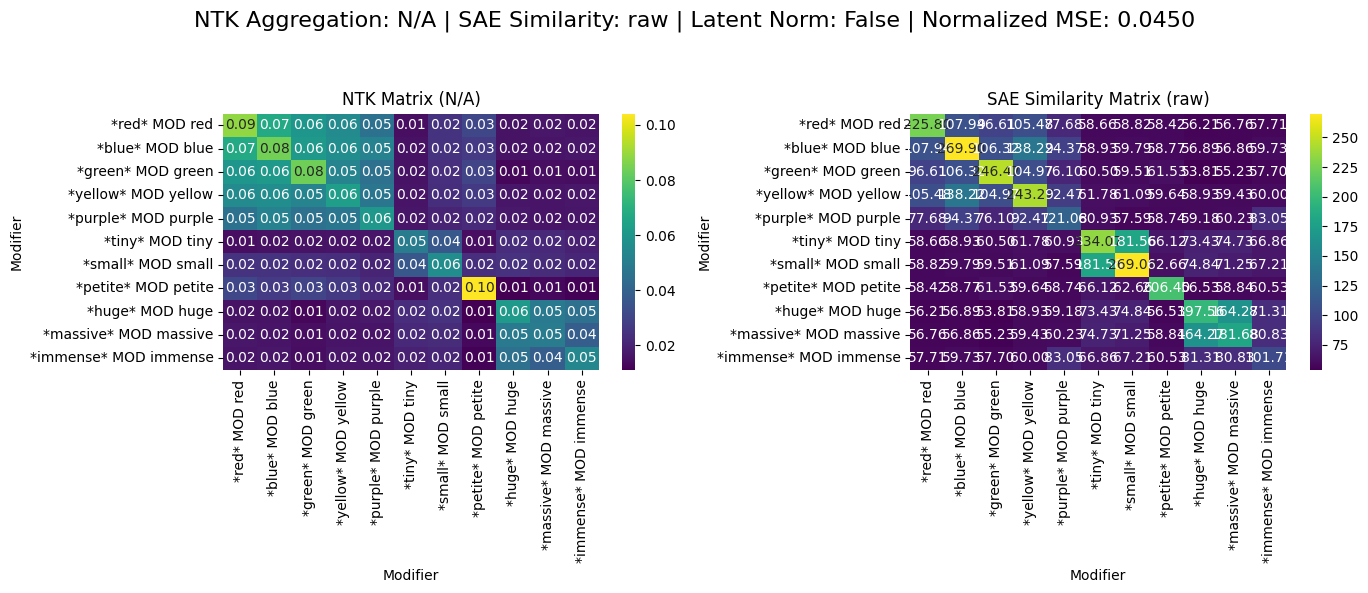

--- Experiment 2 ---
ntk_aggregation: N/A
sae_similarity: cosine
latent_normalization: False
layer_index: 6
location: resid_post_mlp
target_focus: middle string
target_word: ['red', 'blue', 'green', 'yellow', 'purple', 'tiny', 'small', 'petite', 'huge', 'massive', 'immense']
prompt_parts_list: [['The ', 'red', ' ball bounces down the street'], ['The ', 'blue', ' ball bounces down the street'], ['The ', 'green', ' ball bounces down the street'], ['The ', 'yellow', ' ball bounces down the street'], ['The ', 'purple', ' ball bounces down the street'], ['The ', 'tiny', ' ball bounces down the street'], ['The ', 'small', ' ball bounces down the street'], ['The ', 'petite', ' ball bounces down the street'], ['The ', 'huge', ' ball bounces down the street'], ['The ', 'massive', ' ball bounces down the street'], ['The ', 'immense', ' ball bounces down the street']]
modifiers: ['red', 'blue', 'green', 'yellow', 'purple', 'tiny', 'small', 'petite', 'huge', 'massive', 'immense']


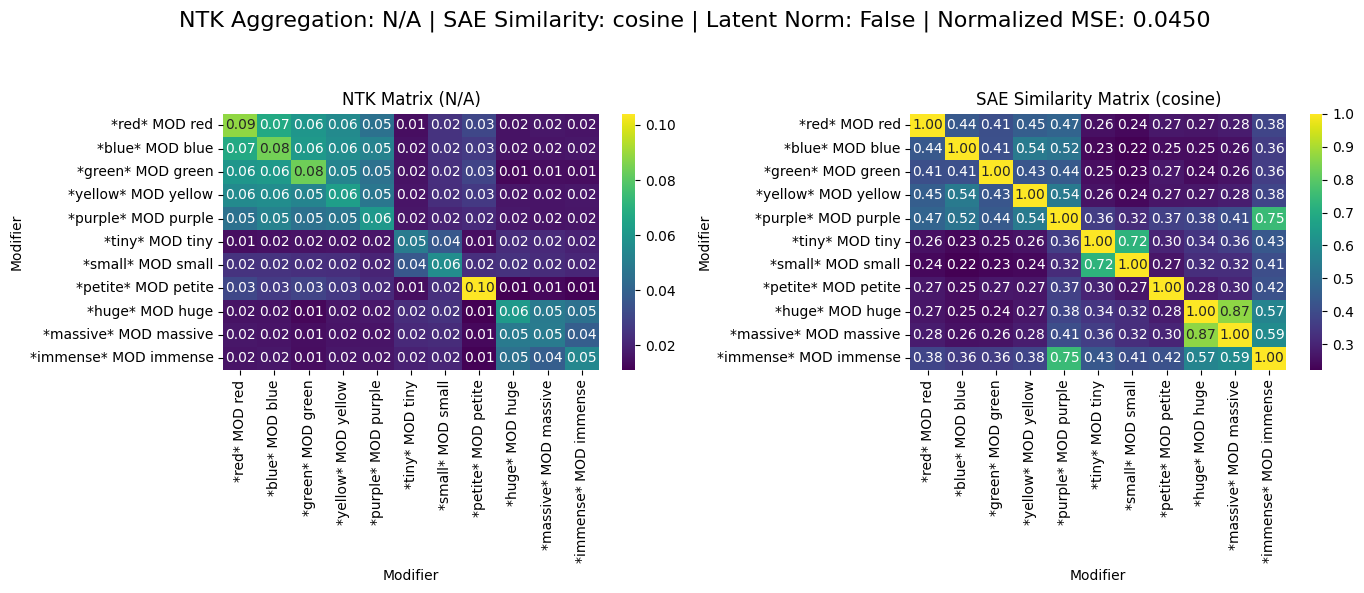

In [77]:

# --- Example: Loop over experiment results and plot each ---
for i, res in enumerate(results_list_describer[:2]):
    print(f"--- Experiment {i+1} ---")
    for key, value in res["metadata"].items():
        print(f"{key}: {value}")
    plot_target_experiment_result(res, norm_method="none", remove_diagonal=False, figsize=(14,6))




## plot "ball" -- ['The red ', 'ball', 

--- Experiment 1 ---
ntk_aggregation: N/A
sae_similarity: raw
latent_normalization: False
layer_index: 6
location: resid_post_mlp
target_focus: middle string
target_word: ['ball', 'ball', 'ball', 'ball', 'ball', 'ball', 'ball', 'ball', 'ball', 'ball', 'ball']
prompt_parts_list: [['The red ', 'ball', ' bounces down the street'], ['The blue ', 'ball', ' bounces down the street'], ['The green ', 'ball', ' bounces down the street'], ['The yellow ', 'ball', ' bounces down the street'], ['The purple ', 'ball', ' bounces down the street'], ['The tiny ', 'ball', ' bounces down the street'], ['The small ', 'ball', ' bounces down the street'], ['The petite ', 'ball', ' bounces down the street'], ['The huge ', 'ball', ' bounces down the street'], ['The massive ', 'ball', ' bounces down the street'], ['The immense ', 'ball', ' bounces down the street']]
modifiers: ['red', 'blue', 'green', 'yellow', 'purple', 'tiny', 'small', 'petite', 'huge', 'massive', 'immense']


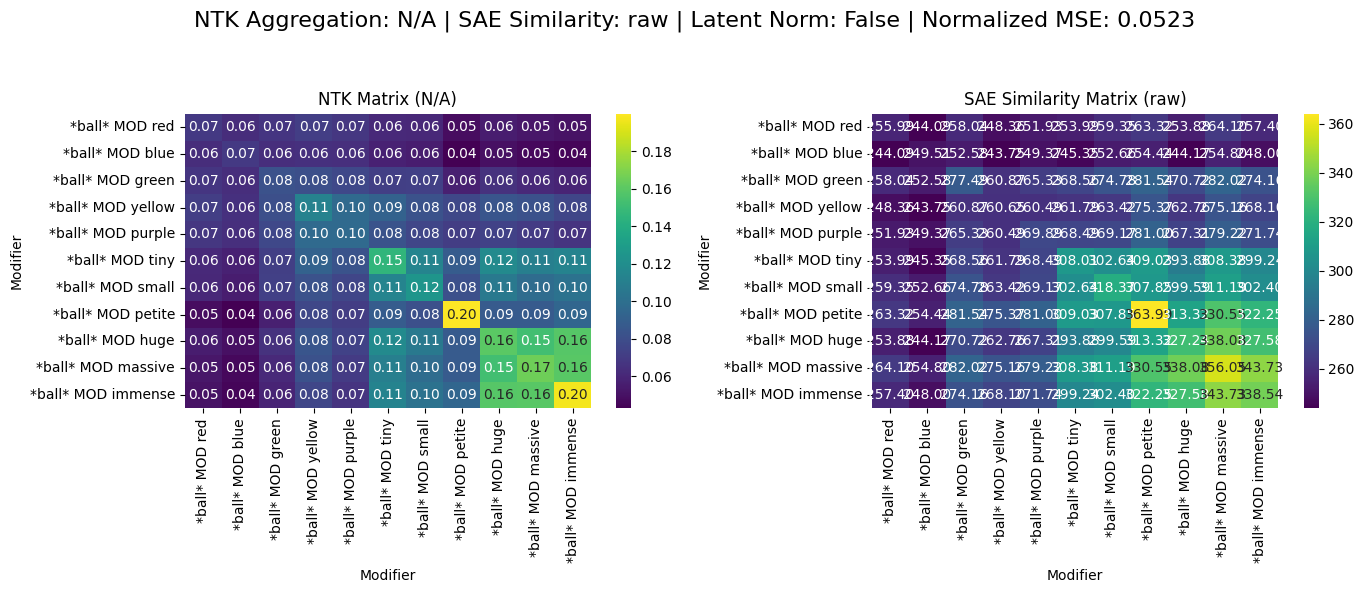

--- Experiment 2 ---
ntk_aggregation: N/A
sae_similarity: cosine
latent_normalization: False
layer_index: 6
location: resid_post_mlp
target_focus: middle string
target_word: ['ball', 'ball', 'ball', 'ball', 'ball', 'ball', 'ball', 'ball', 'ball', 'ball', 'ball']
prompt_parts_list: [['The red ', 'ball', ' bounces down the street'], ['The blue ', 'ball', ' bounces down the street'], ['The green ', 'ball', ' bounces down the street'], ['The yellow ', 'ball', ' bounces down the street'], ['The purple ', 'ball', ' bounces down the street'], ['The tiny ', 'ball', ' bounces down the street'], ['The small ', 'ball', ' bounces down the street'], ['The petite ', 'ball', ' bounces down the street'], ['The huge ', 'ball', ' bounces down the street'], ['The massive ', 'ball', ' bounces down the street'], ['The immense ', 'ball', ' bounces down the street']]
modifiers: ['red', 'blue', 'green', 'yellow', 'purple', 'tiny', 'small', 'petite', 'huge', 'massive', 'immense']


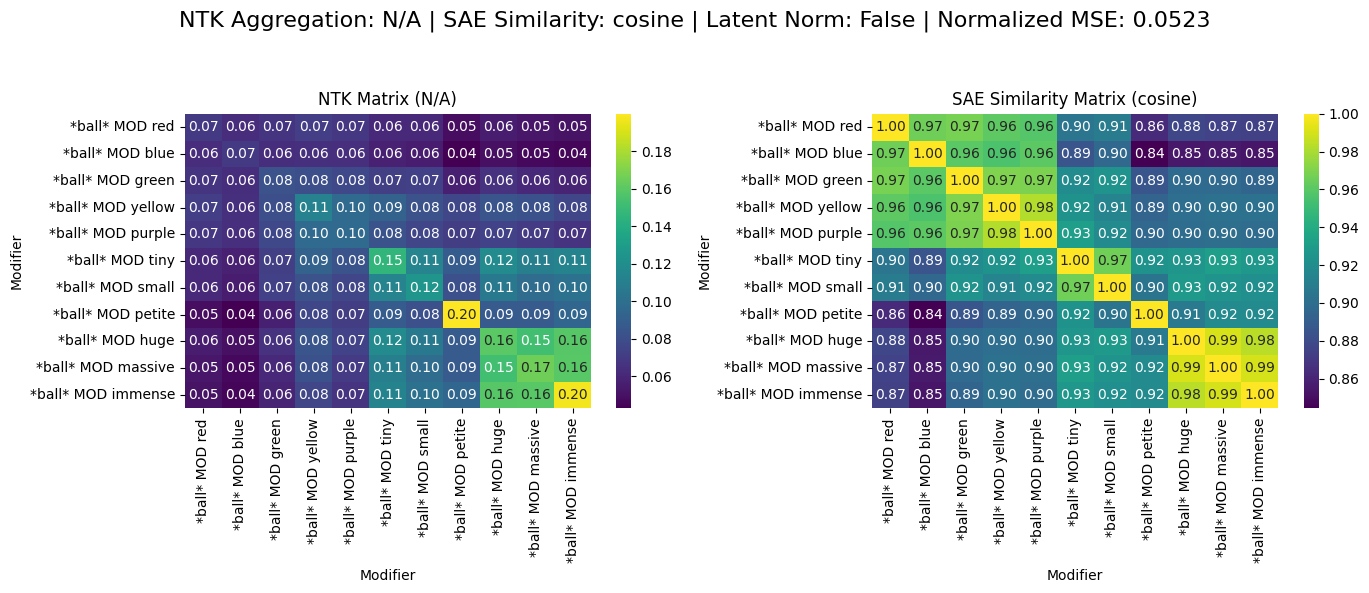

In [78]:

# --- Example: Loop over experiment results and plot each ---
for i, res in enumerate(results_list_ball[:2]):
    print(f"--- Experiment {i+1} ---")
    for key, value in res["metadata"].items():
        print(f"{key}: {value}")
    plot_target_experiment_result(res, norm_method="none", remove_diagonal=False, figsize=(14,6))





## plot "ball" long sentence -- ['The ball sits at the edge of the curb. A car drives by, shaking the ground slightly. A breeze picks up. The red ', 'ball', 

--- Experiment 1 ---
ntk_aggregation: N/A
sae_similarity: raw
latent_normalization: False
layer_index: 6
location: resid_post_mlp
target_focus: middle string
target_word: ['ball', 'ball', 'ball', 'ball', 'ball', 'ball', 'ball', 'ball', 'ball', 'ball', 'ball']
prompt_parts_list: [['The ball sits at the edge of the curb. A car drives by, shaking the ground slightly. A breeze picks up. The red ', 'ball', ' bounces down the street'], ['The ball sits at the edge of the curb. A car drives by, shaking the ground slightly. A breeze picks up. The blue ', 'ball', ' bounces down the street'], ['The ball sits at the edge of the curb. A car drives by, shaking the ground slightly. A breeze picks up. The green ', 'ball', ' bounces down the street'], ['The ball sits at the edge of the curb. A car drives by, shaking the ground slightly. A breeze picks up. The yellow ', 'ball', ' bounces down the street'], ['The ball sits at the edge of the curb. A car drives by, shaking the ground slightly. A breeze pi

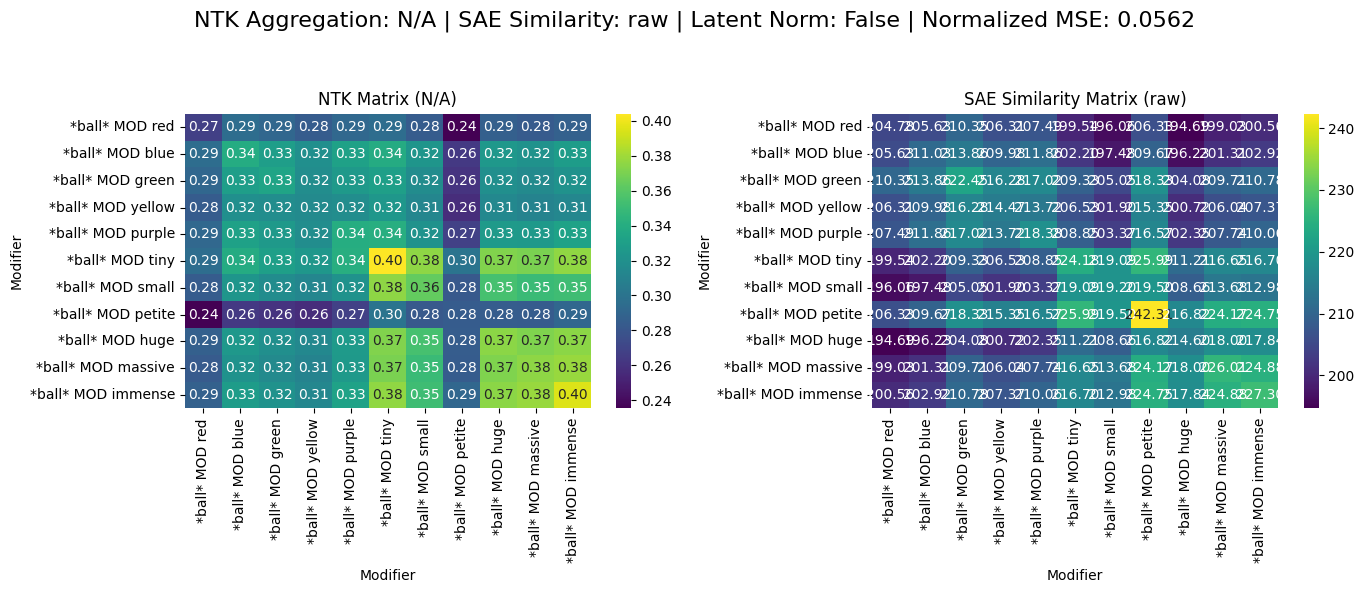

--- Experiment 2 ---
ntk_aggregation: N/A
sae_similarity: cosine
latent_normalization: False
layer_index: 6
location: resid_post_mlp
target_focus: middle string
target_word: ['ball', 'ball', 'ball', 'ball', 'ball', 'ball', 'ball', 'ball', 'ball', 'ball', 'ball']
prompt_parts_list: [['The ball sits at the edge of the curb. A car drives by, shaking the ground slightly. A breeze picks up. The red ', 'ball', ' bounces down the street'], ['The ball sits at the edge of the curb. A car drives by, shaking the ground slightly. A breeze picks up. The blue ', 'ball', ' bounces down the street'], ['The ball sits at the edge of the curb. A car drives by, shaking the ground slightly. A breeze picks up. The green ', 'ball', ' bounces down the street'], ['The ball sits at the edge of the curb. A car drives by, shaking the ground slightly. A breeze picks up. The yellow ', 'ball', ' bounces down the street'], ['The ball sits at the edge of the curb. A car drives by, shaking the ground slightly. A breeze

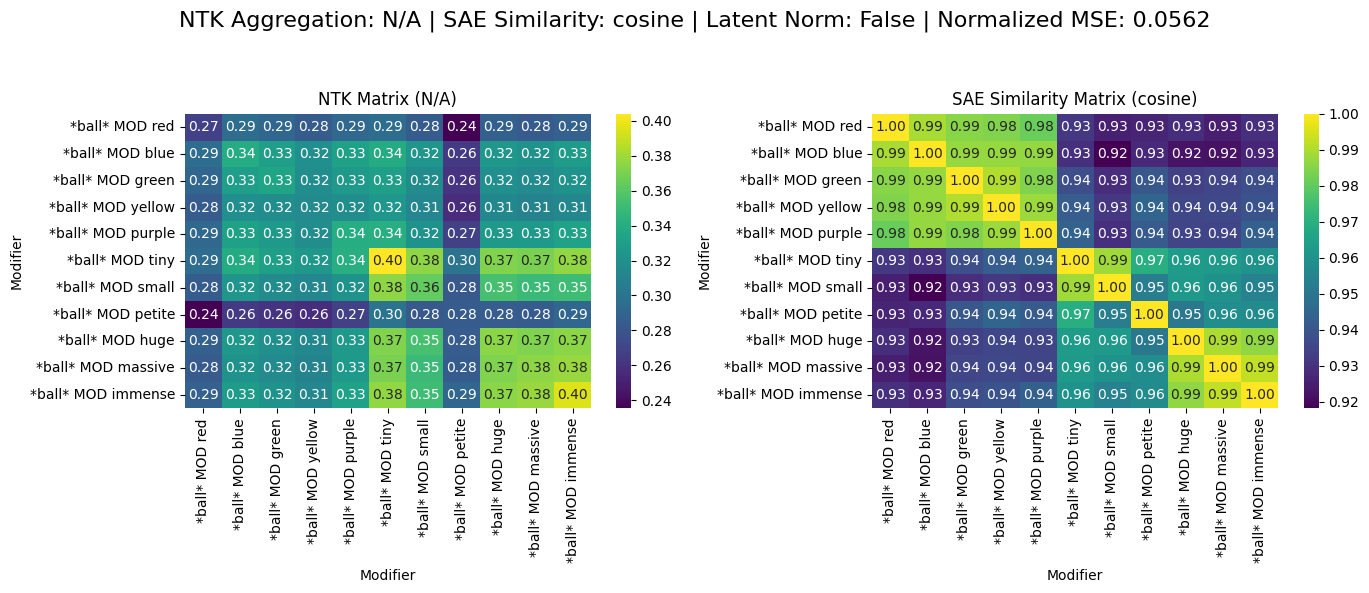

In [79]:


# --- Example: Loop over experiment results and plot each ---
for i, res in enumerate(results_list_ball_long_sentece[:2]):
    print(f"--- Experiment {i+1} ---")
    for key, value in res["metadata"].items():
        print(f"{key}: {value}")
    plot_target_experiment_result(res, norm_method="none", remove_diagonal=False, figsize=(14,6))





## plot "street" -- ['The red ball bounces down the ', 'street'

--- Experiment 1 ---
ntk_aggregation: N/A
sae_similarity: raw
latent_normalization: False
layer_index: 6
location: resid_post_mlp
target_focus: middle string
target_word: ['street', 'street', 'street', 'street', 'street', 'street', 'street', 'street', 'street', 'street', 'street']
prompt_parts_list: [['The red ball bounces down the ', 'street', ''], ['The blue ball bounces down the ', 'street', ''], ['The green ball bounces down the ', 'street', ''], ['The yellow ball bounces down the ', 'street', ''], ['The purple ball bounces down the ', 'street', ''], ['The tiny ball bounces down the ', 'street', ''], ['The small ball bounces down the ', 'street', ''], ['The petite ball bounces down the ', 'street', ''], ['The huge ball bounces down the ', 'street', ''], ['The massive ball bounces down the ', 'street', ''], ['The immense ball bounces down the ', 'street', '']]
modifiers: ['red', 'blue', 'green', 'yellow', 'purple', 'tiny', 'small', 'petite', 'huge', 'massive', 'immense']


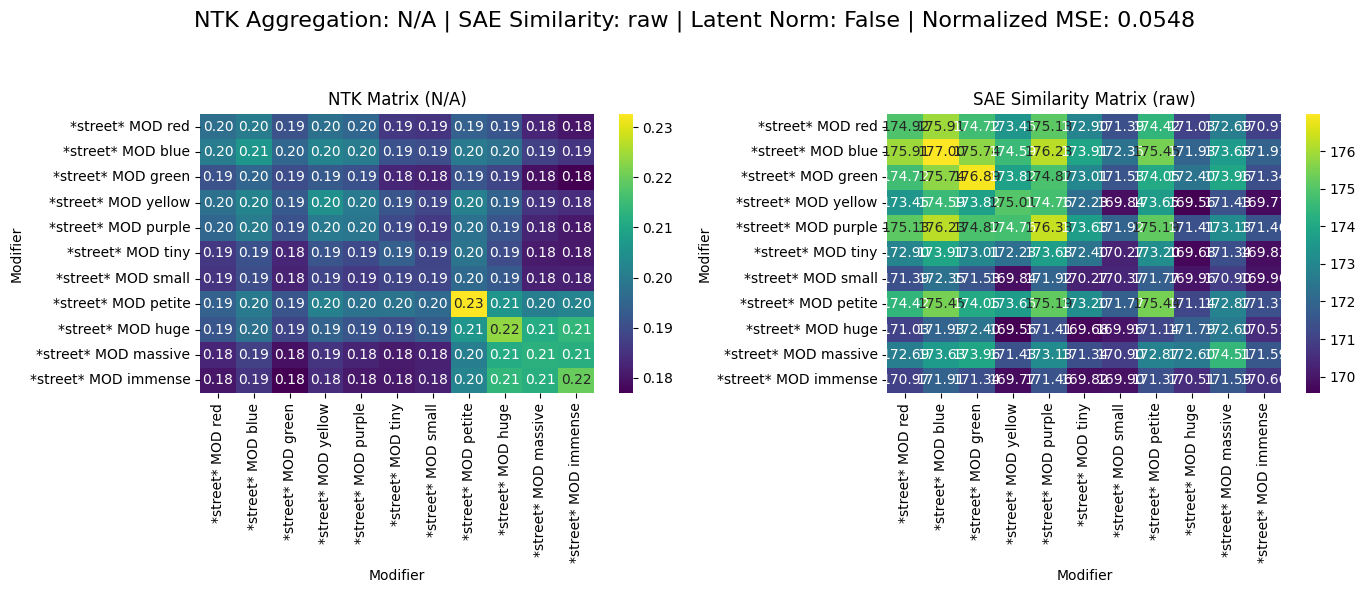

--- Experiment 2 ---
ntk_aggregation: N/A
sae_similarity: cosine
latent_normalization: False
layer_index: 6
location: resid_post_mlp
target_focus: middle string
target_word: ['street', 'street', 'street', 'street', 'street', 'street', 'street', 'street', 'street', 'street', 'street']
prompt_parts_list: [['The red ball bounces down the ', 'street', ''], ['The blue ball bounces down the ', 'street', ''], ['The green ball bounces down the ', 'street', ''], ['The yellow ball bounces down the ', 'street', ''], ['The purple ball bounces down the ', 'street', ''], ['The tiny ball bounces down the ', 'street', ''], ['The small ball bounces down the ', 'street', ''], ['The petite ball bounces down the ', 'street', ''], ['The huge ball bounces down the ', 'street', ''], ['The massive ball bounces down the ', 'street', ''], ['The immense ball bounces down the ', 'street', '']]
modifiers: ['red', 'blue', 'green', 'yellow', 'purple', 'tiny', 'small', 'petite', 'huge', 'massive', 'immense']


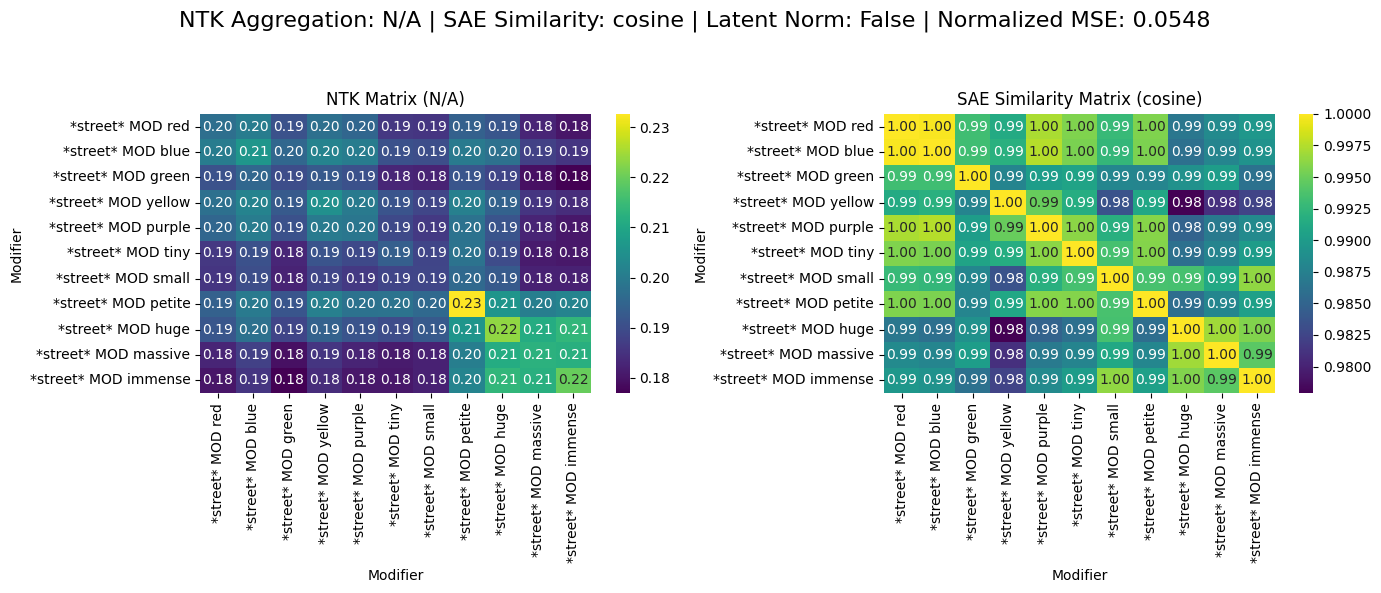

In [80]:

# --- Example: Loop over experiment results and plot each ---
for i, res in enumerate(results_list_street[:2]):
    print(f"--- Experiment {i+1} ---")
    for key, value in res["metadata"].items():
        print(f"{key}: {value}")
    plot_target_experiment_result(res, norm_method="none", remove_diagonal=False, figsize=(14,6))





## plot all -- ['', 'The red ball bounces down the street', '']

--- Experiment 1 ---
ntk_aggregation: N/A
sae_similarity: raw
latent_normalization: False
layer_index: 6
location: resid_post_mlp
target_focus: middle string
target_word: ['The red ball bounces down the street', 'The blue ball bounces down the street', 'The green ball bounces down the street', 'The yellow ball bounces down the street', 'The purple ball bounces down the street', 'The tiny ball bounces down the street', 'The small ball bounces down the street', 'The petite ball bounces down the street', 'The huge ball bounces down the street', 'The massive ball bounces down the street', 'The immense ball bounces down the street']
prompt_parts_list: [['', 'The red ball bounces down the street', ''], ['', 'The blue ball bounces down the street', ''], ['', 'The green ball bounces down the street', ''], ['', 'The yellow ball bounces down the street', ''], ['', 'The purple ball bounces down the street', ''], ['', 'The tiny ball bounces down the street', ''], ['', 'The small ball bounces down 

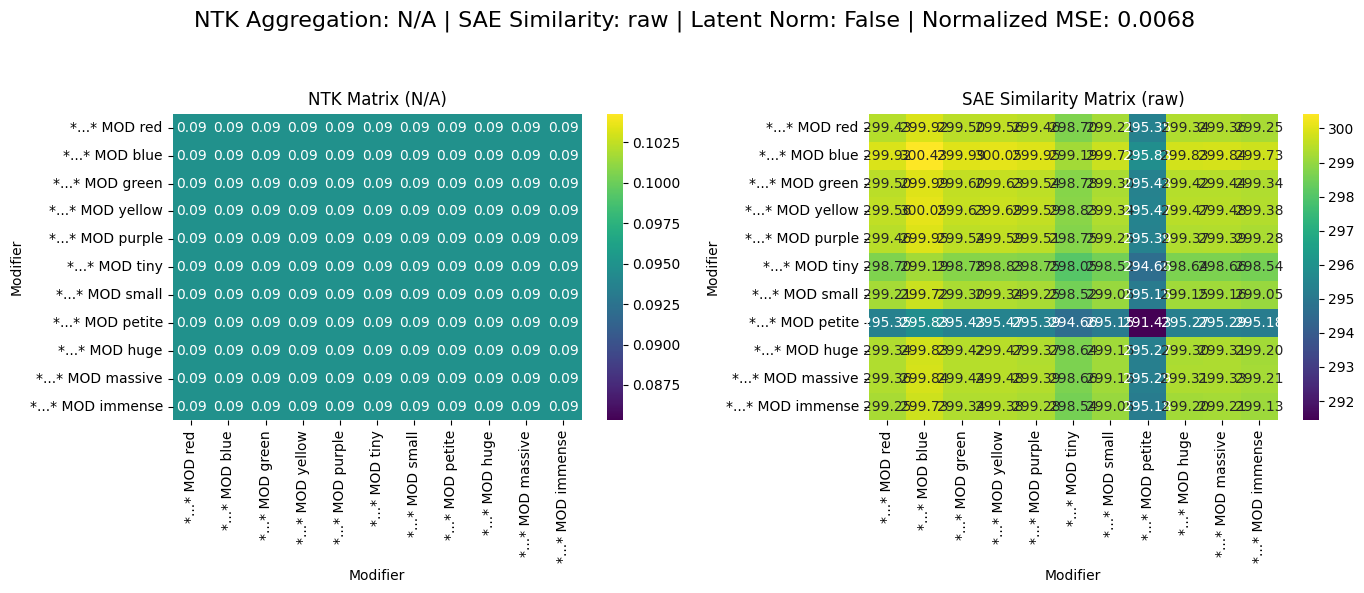

--- Experiment 2 ---
ntk_aggregation: N/A
sae_similarity: cosine
latent_normalization: False
layer_index: 6
location: resid_post_mlp
target_focus: middle string
target_word: ['The red ball bounces down the street', 'The blue ball bounces down the street', 'The green ball bounces down the street', 'The yellow ball bounces down the street', 'The purple ball bounces down the street', 'The tiny ball bounces down the street', 'The small ball bounces down the street', 'The petite ball bounces down the street', 'The huge ball bounces down the street', 'The massive ball bounces down the street', 'The immense ball bounces down the street']
prompt_parts_list: [['', 'The red ball bounces down the street', ''], ['', 'The blue ball bounces down the street', ''], ['', 'The green ball bounces down the street', ''], ['', 'The yellow ball bounces down the street', ''], ['', 'The purple ball bounces down the street', ''], ['', 'The tiny ball bounces down the street', ''], ['', 'The small ball bounces do

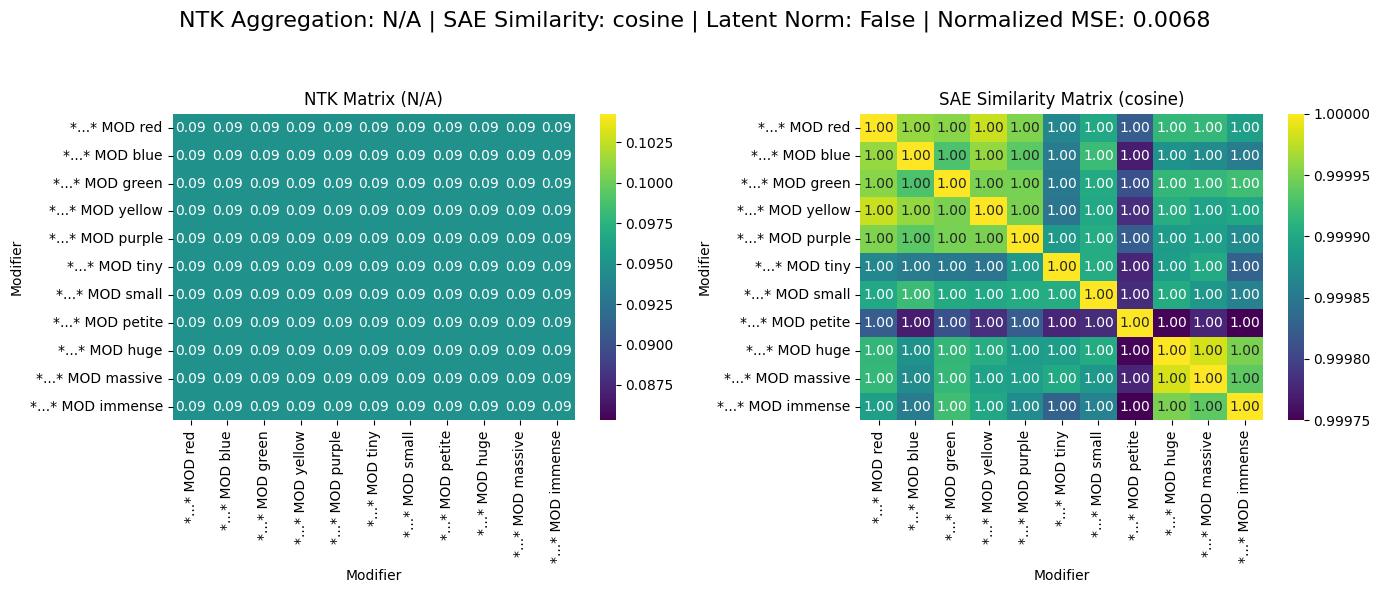

In [81]:


# --- Example: Loop over experiment results and plot each ---
for i, res in enumerate(results_list_all[:2]):
    print(f"--- Experiment {i+1} ---")
    for key, value in res["metadata"].items():
        print(f"{key}: {value}")
    plot_target_experiment_result(res, norm_method="none", remove_diagonal=False, figsize=(14,6))





# Conclusion

At the word level, the ENTK and SAE at Layer 6 of GPT-2 covary in many cases, but this heavily depends on the approach.

1) As expected, prepending tokens (plot "ball" vs. plot "ball long sentence") changes each representation. Specifically, the ENTK "petite" example shows 'streaking' as it becomes less similar to other examples—something apparent in the short sentence example, and emphasized even more here. For the SAE, the natural clustering of each modifier category becomes more pronounced (colors are more correlated, size words are more correlated, and small/big size words are more correlated).

2) In the "ball" section plot — the NTK doesn’t capture strong similarity for the color modifiers modifying "ball." It resembles the SAE without any normalization and just taking the inner product of the SAE features. Note that after normalization, the SAE very tightly groups the color words that modify "ball."

3) In the "street" section plot, the modifier modifies "ball," and the "ball" interacts with "street"; so "street" is only indirectly related to the modifier word. The ENTK shows a block diagonal for the 'large' modifier only, while the unnormalized SAE shows clustering for the color words only. Note the SAE is largely saturated in this example, especially after normalization.

5) In the "all" section plot, all the similarities collapse to be the same — this is a control.

## Final thoughts

Even with largely identical input strings, choice of normalization method and length of input string can affect results, at least at the token level. Controlling for as many factors as possible is advisable, especially as we scale up to larger models.
